# Code

In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('..\data\cleaned\employment_cleaned.csv')


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\micro\AppData\Local\Temp\ipykernel_12524\3081294922.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('..\data\cleaned\employment_cleaned.csv')


In [3]:
df.head()

,id,AgeAbove35,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,0,0,False,Master,1,Man,False,Dev,7,4,Sweden,51552.0,"['C++', 'Python', 'Git', 'PostgreSQL']",4,0
1,1,0,False,Undergraduate,1,Man,False,Dev,12,5,Spain,46482.0,"['Bash/Shell', 'HTML/CSS', 'JavaScript', 'Node...",12,1
2,2,0,False,Master,1,Man,False,Dev,15,6,Germany,77290.0,"['C', 'C++', 'Java', 'Perl', 'Ruby', 'Git', 'R...",7,0
3,3,0,False,Undergraduate,1,Man,False,Dev,9,6,Canada,46135.0,"['Bash/Shell', 'HTML/CSS', 'JavaScript', 'PHP'...",13,0
4,4,1,False,PhD,0,Man,False,NotDev,40,30,Singapore,160932.0,"['C++', 'Python']",2,0


In [4]:
skills = pd.read_csv('..\data\cleaned\skills.csv')
skills.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\micro\AppData\Local\Temp\ipykernel_12524\3753810569.py:1: SyntaxWarning: invalid escape sequence '\d'
  skills = pd.read_csv('..\data\cleaned\skills.csv')


,id,HaveWorkedWith
0,0,C++
1,0,Python
2,0,Git
3,0,PostgreSQL
4,1,Bash/Shell


## Feature Engineering

In [5]:
top_countries = df['Country'].value_counts().head(5).index
df['Country_grouped'] = df['Country'].where(df['Country'].isin(top_countries), 'Other')
df['Country_grouped'].value_counts()

Country_grouped
Other                                                   40544
United States of America                                14696
Germany                                                  5395
India                                                    5360
United Kingdom of Great Britain and Northern Ireland     4688
Canada                                                   2779
Name: count, dtype: int64

Countries have 172 unique values , instead we just use the top 10 countries in our analysis and the rest are put in 'others'

In [6]:
df['Skills_dist'] = pd.qcut(df['ComputerSkills'], q=3, labels=['Low','Medium','High'])

print(df['Skills_dist'].value_counts().sort_values(ascending=False))

Skills_dist
Low       27422
High      24169
Medium    21871
Name: count, dtype: int64


In [7]:
df['ComputerSkills'].describe()

count    73462.000000
mean        13.428221
std          7.057835
min          0.000000
25%          8.000000
50%         13.000000
75%         17.000000
max        107.000000
Name: ComputerSkills, dtype: float64

to make easy comparisons using skills 

In [8]:
df['has_advanced_degree'] = df['EdLevel'].isin(['Master', 'PhD']).astype(int)
df['skills_x_advanced_degree'] = df['ComputerSkills'] * df['has_advanced_degree']
df['skills_x_advanced_degree']

0        4
1        0
2        7
3        0
4        2
        ..
73457    0
73458    0
73459    0
73460    0
73461    2
Name: skills_x_advanced_degree, Length: 73462, dtype: int64

as we found skills matter more than the degree itself

In [9]:
df['salary_per_year_exp'] = df['PreviousSalary'] / (df['YearsCodePro'] + 1)
df['salary_per_year_exp'] 

0        10310.400000
1         7747.000000
2        11041.428571
3         6590.714286
4         5191.354839
             ...     
73457    13686.000000
73458     6764.705882
73459    14430.000000
73460    35000.000000
73461    18846.000000
Name: salary_per_year_exp, Length: 73462, dtype: float64

to show how efficient the experience converts to pay 

In [10]:
df['NoHigherEd'] = df['EdLevel'] == 'NoHigherEd'

In [11]:
df['HasTopCountry'] = ~(df['Country_grouped'] == 'Other')

## Preprocessing

In [12]:
df.head()

,id,AgeAbove35,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,...,HaveWorkedWith,ComputerSkills,Employed,Country_grouped,Skills_dist,has_advanced_degree,skills_x_advanced_degree,salary_per_year_exp,NoHigherEd,HasTopCountry
0,0,0,False,Master,1,Man,False,Dev,7,4,...,"['C++', 'Python', 'Git', 'PostgreSQL']",4,0,Other,Low,1,4,10310.400000,False,False
1,1,0,False,Undergraduate,1,Man,False,Dev,12,5,...,"['Bash/Shell', 'HTML/CSS', 'JavaScript', 'Node...",12,1,Other,Medium,0,0,7747.000000,False,False
2,2,0,False,Master,1,Man,False,Dev,15,6,...,"['C', 'C++', 'Java', 'Perl', 'Ruby', 'Git', 'R...",7,0,Germany,Low,1,7,11041.428571,False,True
3,3,0,False,Undergraduate,1,Man,False,Dev,9,6,...,"['Bash/Shell', 'HTML/CSS', 'JavaScript', 'PHP'...",13,0,Canada,Medium,0,0,6590.714286,False,True
4,4,1,False,PhD,0,Man,False,NotDev,40,30,...,"['C++', 'Python']",2,0,Other,Low,1,2,5191.354839,False,False


In [13]:
df['Accessibility'] = df['Accessibility'].map({False:0, True:1})

In [14]:
df['MentalHealth'] = df['MentalHealth'].map({False:0, True:1})

In [15]:
df['NoHigherEd'] = df['NoHigherEd'].map({False:0, True:1})

In [16]:
df['HasTopCountry'] = df['HasTopCountry'].map({False:0, True:1})

In [17]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True, dtype=int)

In [18]:
df = pd.get_dummies(df, columns=['MainBranch'], drop_first=True, dtype=int)

In [19]:
df['Skills_dist'] = pd.to_numeric(df['Skills_dist'].map({'Low':0, 'Medium':1, 'High':2}))

In [20]:
df.select_dtypes(exclude='number').head()

,EdLevel,Country,HaveWorkedWith,Country_grouped
0,Master,Sweden,"['C++', 'Python', 'Git', 'PostgreSQL']",Other
1,Undergraduate,Spain,"['Bash/Shell', 'HTML/CSS', 'JavaScript', 'Node...",Other
2,Master,Germany,"['C', 'C++', 'Java', 'Perl', 'Ruby', 'Git', 'R...",Germany
3,Undergraduate,Canada,"['Bash/Shell', 'HTML/CSS', 'JavaScript', 'PHP'...",Canada
4,PhD,Singapore,"['C++', 'Python']",Other


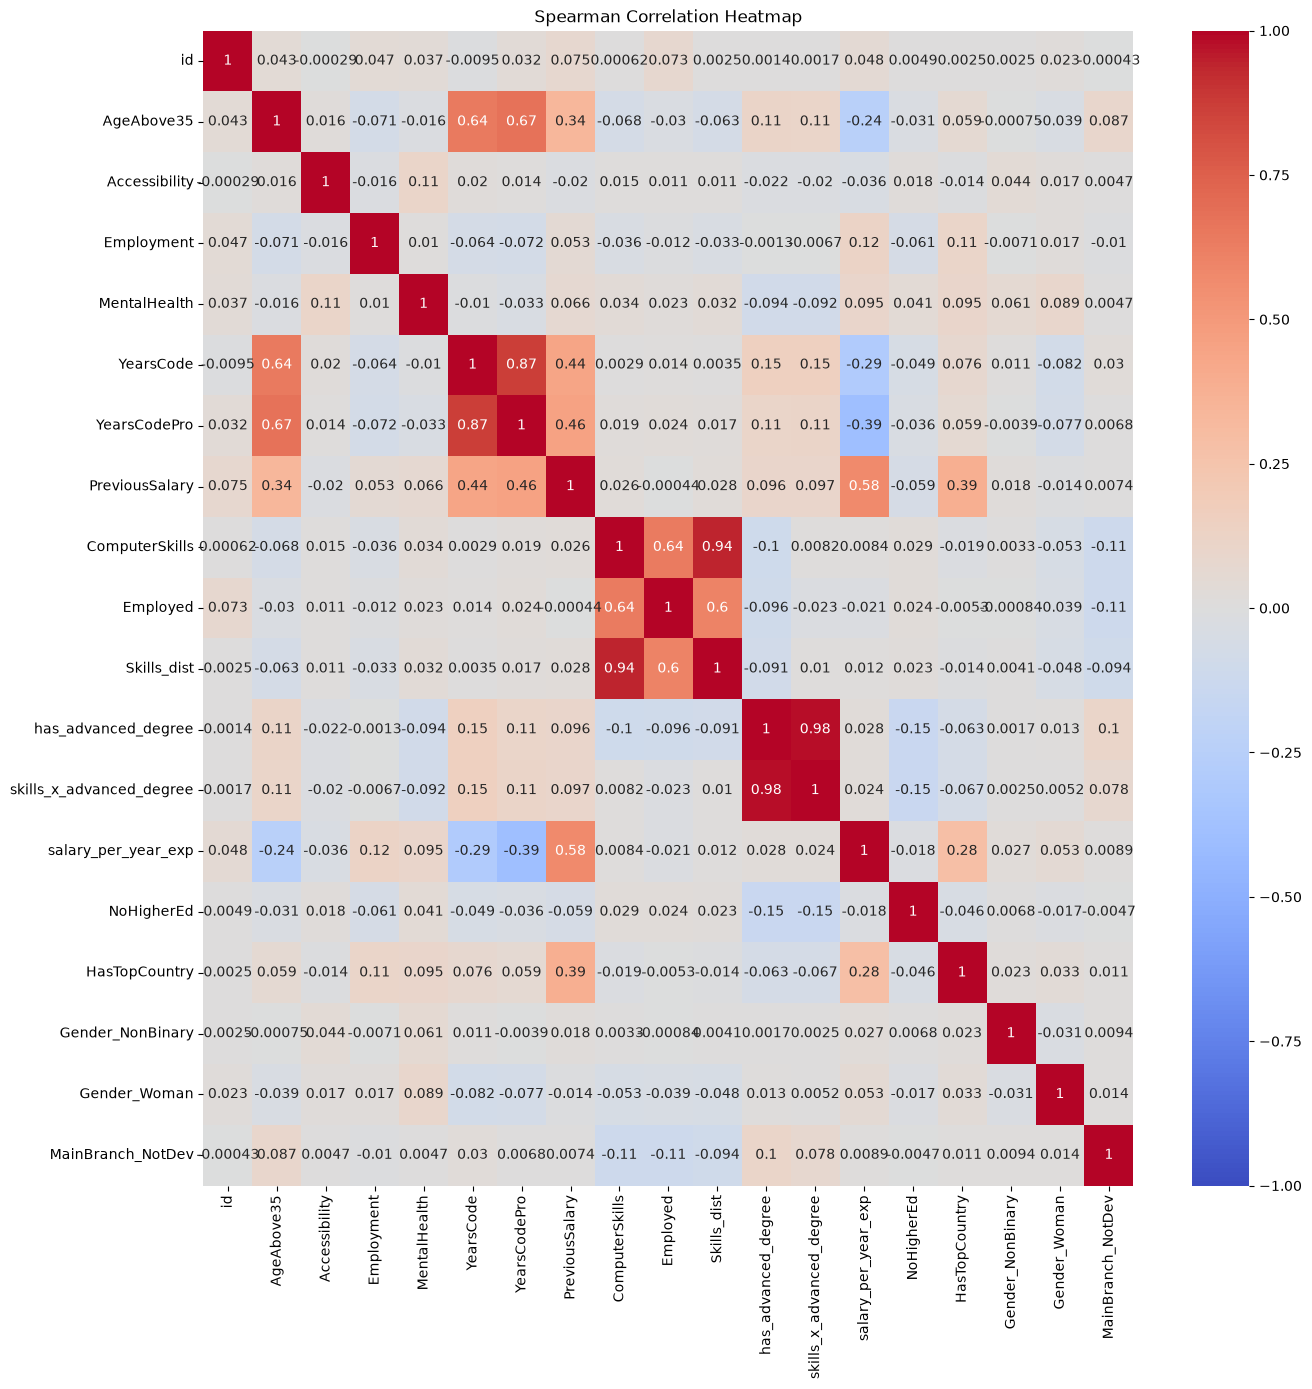

In [21]:
plt.figure(figsize=(15, 15))
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(method='spearman'), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Spearman Correlation Heatmap")
plt.show()

In [22]:
df.isna().any()

id                          False
AgeAbove35                  False
Accessibility               False
EdLevel                     False
Employment                  False
MentalHealth                False
YearsCode                   False
YearsCodePro                False
Country                     False
PreviousSalary              False
HaveWorkedWith               True
ComputerSkills              False
Employed                    False
Country_grouped             False
Skills_dist                 False
has_advanced_degree         False
skills_x_advanced_degree    False
salary_per_year_exp         False
NoHigherEd                  False
HasTopCountry               False
Gender_NonBinary            False
Gender_Woman                False
MainBranch_NotDev           False
dtype: bool

In [23]:
columns_to_exclude = ['id', 'HaveWorkedWith', 'Country', 'Country_grouped', 'ComputerSkills', 'Gender_NonBinary', 'YearsCode', 'PreviousSalary', 'skills_x_advanced_degree', 'EdLevel']

In [24]:
df = df.drop(columns_to_exclude, axis=1)

In [25]:
df.head()

,AgeAbove35,Accessibility,Employment,MentalHealth,YearsCodePro,Employed,Skills_dist,has_advanced_degree,salary_per_year_exp,NoHigherEd,HasTopCountry,Gender_Woman,MainBranch_NotDev
0,0,0,1,0,4,0,0,1,10310.400000,0,0,0,0
1,0,0,1,0,5,1,1,0,7747.000000,0,0,0,0
2,0,0,1,0,6,0,0,1,11041.428571,0,1,0,0
3,0,0,1,0,6,0,1,0,6590.714286,0,1,0,0
4,1,0,0,0,30,0,0,1,5191.354839,0,0,0,1


## Exporting Data

In [26]:
df.to_csv('../data/preprocessed/employment_preprocessed.csv', index=False)